# Análise de dados sobre saúde do sono e estilo de vida

### Insights sobre padrões de sono e hábitos diários

# Visão geral do projeto:
O Sleep Health and Lifestyle Dataset fornece insights detalhados sobre os padrões de sono, hábitos diários e fatores de estilo de vida dos indivíduos. Essa etapa do projeto compreende dados já tratados e organizados para facilitar as análises. 

Essa análise tem como objetivo produzir insights a partir de métricas essenciais como duração do sono, qualidade do sono, níveis de atividade física, estresse, categoria de IMC, saúde cardiovascular e presença de distúrbios do sono.

# Fontes dos dados

Os dados foram obtidos no kaggle através do [link](https://www.kaggle.com/code/winterbearballu/sleep-health-and-lifestyle-eda)

Obs: este conjunto de dados é gerado sinteticamente e se destina exclusivamente a propósitos ilustrativos e educacionais. Ele visa fornecer uma estrutura realista para explorar e analisar correlações entre sono, hábitos de estilo de vida e métricas de saúde.

# Otimizando o desbalanceamento

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder, 
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import organiza_resultados, RANDOM_STATE

sns.set_theme(palette="bright")

In [6]:
df = pd.read_parquet(DADOS_LIMPOS)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Genero                  400 non-null    category
 1   Idade                   400 non-null    int8    
 2   Ocupacao                400 non-null    category
 3   Duracao_sono            400 non-null    float32 
 4   Qualidade_sono          400 non-null    float32 
 5   Nivel_atividade_física  400 non-null    int8    
 6   Nivel_estresse          400 non-null    int8    
 7   IMC                     400 non-null    category
 8   Frequencia_cardiaca     400 non-null    int8    
 9   Passos_diarios          400 non-null    int16   
 10  Disturbio_sono          400 non-null    category
 11  Sistolica               400 non-null    int16   
 12  Diastolica              400 non-null    int8    
dtypes: category(4), float32(2), int16(2), int8(5)
memory usage: 9.0 KB


## Estruturação do modelo

In [8]:
# Separação do target das demais colunas

X = df.drop(columns="Disturbio_sono")
y = df["Disturbio_sono"]

In [9]:
# Codificando para obter um target numérico

le = LabelEncoder()

y = le.fit_transform(y)

y[:20]

array([1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 0])

In [10]:
# Selecionar colunas para o pré-processamento

coluna_target = ["Disturbio_sono"]

colunas_categoricas_ordinais =["IMC"]

ordem_imc = [["Underweight", "Normal", "Overweight", "Obese"]]

colunas_categoricas_nominais = df.select_dtypes(include="category").columns.difference(colunas_categoricas_ordinais + coluna_target).to_list()

colunas_numericas= df.select_dtypes(include="number").columns.to_list()

Agora que foi observado no notebook anterior que não houve melhoria adicional com a inclusão do tratamento de escala para as variáveis, estaremos adicionando mais uma camada para tratar o desbalanceamento e vermos comparativamente o desempenho dos modelos.

In [12]:
# Dicionário de pré-processamento

preprocessamento_categoricas = ColumnTransformer(
    transformers=[
        ("ordinal_encoder", OrdinalEncoder(categories=ordem_imc), colunas_categoricas_ordinais),
        ("one_hot_encoder", OneHotEncoder(), colunas_categoricas_nominais)
    ],
    remainder="passthrough",
)

preprocessamento_completo = ColumnTransformer(
    transformers=[
        ("ordinal_encoder", OrdinalEncoder(categories=ordem_imc), colunas_categoricas_ordinais),
        ("one_hot_encoder", OneHotEncoder(), colunas_categoricas_nominais),
        ("StandardScaler", StandardScaler(), colunas_numericas),
    ],
    remainder="passthrough",
)

In [13]:
# Dicionário de Regressores

classificadores = {
    "DummyClassifier":{
        "preprocessor": None,
        "inbalanced": None,
        "classificador": DummyClassifier(strategy="stratified"),
    },
    "Logistic_regression_cat":{
        "preprocessor": preprocessamento_categoricas,
        "inbalanced": None,
        "classificador": LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced"),
    },
    "Logistic_regression_cat_RUS":{
        "preprocessor": preprocessamento_categoricas,
        "inbalanced": RandomUnderSampler(random_state=RANDOM_STATE),
        "classificador": LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced"),
    },
    "Logistic_regression_completo_RUS":{
        "preprocessor": preprocessamento_categoricas,
        "inbalanced": RandomUnderSampler(random_state=RANDOM_STATE),
        "classificador": LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced"),
    },
    "Logistic_regression_cat_ROS":{
        "preprocessor": preprocessamento_categoricas,
        "inbalanced": RandomOverSampler(random_state=RANDOM_STATE),
        "classificador": LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced"),
    },

    "Logistic_regression_completo_ROS":{
        "preprocessor": preprocessamento_categoricas,
        "inbalanced": RandomOverSampler(random_state=RANDOM_STATE),
        "classificador": LogisticRegression(max_iter=5000, solver="saga", class_weight="balanced"),
    },
}

Novamente foi realizada mais uma alteração na estrutura visando a análise comparativa considerando o desbalanceamento.

Foram incluídos os tratamentos:

- RandomUnderSampler: reduz o desbalanceamento removendo amostras da classe majoritária até equilibrar com a minoritária.
- RandomOverSampler: reduz o desbalanceamento duplicando aleatoriamente amostras da classe minoritária até equilibrar com a majoritária.

Mesmo com desempenho inferior, manteremos o pré-processamento completo (com ajuste de escala) para avaliar o comportamento considerando o tratamento do desbalanceamento

In [15]:
# Construindo a pipeline

pipelines = {
    nome: Pipeline(steps=[("preprocessor", estrutura["preprocessor"]), ("Inbalanced", estrutura["inbalanced"]), ("clf", estrutura["classificador"])])
    for nome, estrutura in classificadores.items()
}

pipelines["Logistic_regression_cat_RUS"]

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obese']]),
                                                  ['IMC']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Genero', 'Ocupacao'])])),
                ('Inbalanced', RandomUnderSampler(random_state=42)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    solver='saga'))])

In [16]:
# Validação cruzada

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados = {
    nome: cross_validate(
        pipe,
        X,
        y,
        cv=kf,
        scoring=[
            "accuracy",
            "balanced_accuracy",
            "f1_weighted",
            "precision_weighted",
            "recall_weighted",
            "roc_auc_ovr",
            "average_precision",
        ],
    )
    for nome, pipe in pipelines.items()
}

C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\L

In [17]:
df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
0,DummyClassifier,0.002997,0.025494,0.6,0.401102,0.611806,0.626389,0.6,0.460791,0.328489,0.028491
1,DummyClassifier,0.006001,0.022389,0.625,0.332615,0.609296,0.595751,0.625,0.489829,0.332326,0.02839
2,DummyClassifier,0.001999,0.020793,0.5625,0.303879,0.556876,0.551396,0.5625,0.461054,0.322083,0.022792
3,DummyClassifier,0.002059,0.015627,0.5,0.244971,0.50386,0.507817,0.5,0.513308,0.343315,0.017686
4,DummyClassifier,0.0,0.015625,0.6125,0.372906,0.601728,0.594211,0.6125,0.472385,0.330718,0.015625
5,Logistic_regression_cat,1.191129,0.063052,0.4375,0.415469,0.488664,0.616929,0.4375,0.637062,0.430041,1.254181
6,Logistic_regression_cat,1.686835,0.031824,0.5125,0.475575,0.557444,0.65125,0.5125,0.55598,0.40582,1.718659
7,Logistic_regression_cat,1.125065,0.063587,0.4,0.328784,0.463071,0.583893,0.4,0.480498,0.367866,1.188652
8,Logistic_regression_cat,1.294175,0.031791,0.4125,0.334531,0.46646,0.569925,0.4125,0.547626,0.436003,1.325966
9,Logistic_regression_cat,1.270231,0.053974,0.4625,0.413082,0.521481,0.659393,0.4625,0.63609,0.405906,1.324205


In [18]:
# Agrupando resultados pela média

df_resultados.groupby("model").mean().sort_values("test_balanced_accuracy")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1_weighted,test_precision_weighted,test_recall_weighted,test_roc_auc_ovr,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.002611,0.019986,0.58,0.331095,0.576713,0.575113,0.58,0.479473,0.331386,0.022597
Logistic_regression_cat_RUS,0.400818,0.039353,0.4275,0.363734,0.485509,0.612241,0.4275,0.577264,0.405662,0.44017
Logistic_regression_completo_RUS,0.412272,0.045491,0.4275,0.363734,0.485509,0.612241,0.4275,0.577198,0.405662,0.457763
Logistic_regression_cat,1.313487,0.048846,0.445,0.393488,0.499424,0.616278,0.445,0.571451,0.409127,1.362333
Logistic_regression_cat_ROS,3.367332,0.041136,0.44,0.40298,0.491423,0.606106,0.44,0.565736,0.404857,3.408468
Logistic_regression_completo_ROS,3.355908,0.03772,0.44,0.40298,0.491423,0.606106,0.44,0.565671,0.404857,3.393628


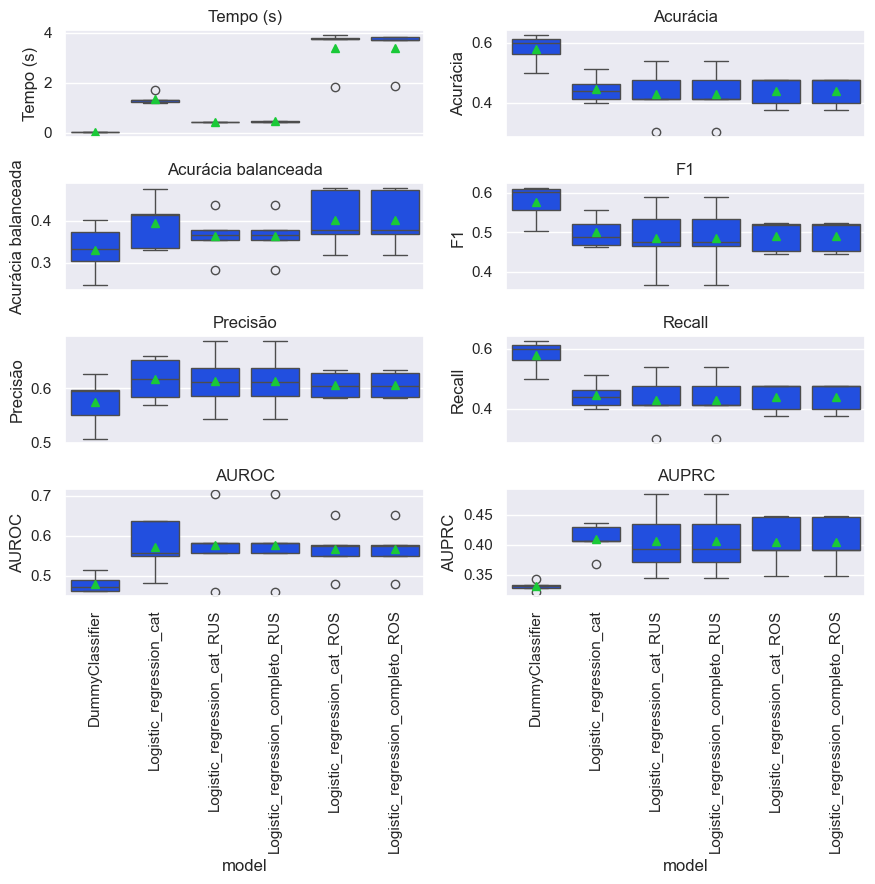

In [19]:
plot_comparar_metricas_modelos(df_resultados, multi_class=True)

Após o tratamento do desbalanceamento, podemos notar novamente que não houve melhora considerável nas métricas do melhor modelo.

No entanto, o uso do RandomUnderSampler reduziu o tempo de execução em cerca de três vezes em comparação ao modelo mais simples, o que representa um ganho relevante de eficiência. 

Essa economia de tempo é bastante relevante em cenários com grandes volumes de dados, onde a redução no custo computacional pode ser tão importante quanto a melhoria nas métricas.

Pelos motivos apontados acima, por conta da eficiência do tempo de execução, o modelo escolhido para otimização será o de Regressão Logística utilizando tratamento das categóricas e o desbalanceamento com RandonUnderSampler.

## Otimização do modelo escolhido

Utilizaremos o grid search para otimizar o modelo escolhido a fim de esgotar as possibilidades de melhoria de performance do modelo.

In [24]:
# Grade de parâmetros

param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__penalty": ["l1", "l2", "elasticnet", None],
    "clf__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9],
}

In [25]:
grid_search = GridSearchCV(
    pipelines["Logistic_regression_cat_RUS"], 
    param_grid=param_grid, 
    cv=kf, 
    scoring="roc_auc_ovr", 
    n_jobs=-1
)

In [26]:
grid_search.fit(X, y)

C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\ml_aula\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ordinal_encoder',
                                                                         OrdinalEncoder(categories=[['Underweight',
                                                                                                     'Normal',
                                                                                                     'Overweight',
                                                                                                     'Obese']]),
                                                                         ['IMC']),
                                                                        ('one_hot_encoder',
                                                                         OneHotEncoder(),
                                                                         ['Genero',
                                                                          'Ocupacao'])])),
                                       ('Inbalanced',
                                        RandomUnderSampler(random_state=42)),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['l1', 'l2', 'elasticnet', None]},
             scoring='roc_auc_ovr')

In [27]:
grid_search.best_params_

{'clf__C': 0.1, 'clf__l1_ratio': 0.25, 'clf__penalty': 'l1'}

In [28]:
grid_search.best_score_

np.float64(0.5793057059626461)

In [29]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal_encoder',
                                                  OrdinalEncoder(categories=[['Underweight',
                                                                              'Normal',
                                                                              'Overweight',
                                                                              'Obese']]),
                                                  ['IMC']),
                                                 ('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Genero', 'Ocupacao'])])),
                ('Inbalanced', RandomUnderSampler(random_state=42)),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    l1_ratio=0.25, max_iter=5000, penalty='l1',
                                    solver='saga'))])

## Avaliando os coeficientes

In [31]:
# Coeficientes gerados a partir do classificador

grid_search.best_estimator_["clf"].coef_

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  2.39901950e-04,
         2.05791989e-05, -2.85740965e-03, -1.24901273e-05,
         1.87794754e-03, -6.47919380e-10,  0.00000000e+00,
         3.75297022e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  9.35053528e-05, -3.87590046e-04,
         0.00000000e+00,  6.98350668e-03, -3.46504581e-05,
        -3.16149074e-04, -2.57563881e-05, -3.69777205e-04,
        -9.29714218e-04],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.67032036e-04,  0.00000000e+00,
         0.00000000e+00, -3.87363465e-03,  2.82143381e-04,
        -1.56549928e-03,  2.26261082e-05,  4.06362858e-04,
         3.88681726e-04]])

In [32]:
# Feature após o treinamento (preprocessamento

grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['ordinal_encoder__IMC', 'one_hot_encoder__Genero_Female',
       'one_hot_encoder__Genero_Male',
       'one_hot_encoder__Ocupacao_Manual Labor',
       'one_hot_encoder__Ocupacao_Office Worker',
       'one_hot_encoder__Ocupacao_Retired',
       'one_hot_encoder__Ocupacao_Student', 'remainder__Idade',
       'remainder__Duracao_sono', 'remainder__Qualidade_sono',
       'remainder__Nivel_atividade_física', 'remainder__Nivel_estresse',
       'remainder__Frequencia_cardiaca', 'remainder__Passos_diarios',
       'remainder__Sistolica', 'remainder__Diastolica'], dtype=object)

In [33]:
# Visualizando os coeficientes mais relevantes para cada classe

coefs = pd.DataFrame(
    data=grid_search.best_estimator_["clf"].coef_, 
    index=le.inverse_transform([0, 1, 2]),
    columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out()
).T.sort_values(by="No sleep disturbance").round(5)

coefs

,Insomnia,No sleep disturbance,Sleep Apnea
remainder__Diastolica,0.00038,-0.00093,0.00039
remainder__Duracao_sono,0.00024,-0.00039,0.00000
remainder__Sistolica,0.00000,-0.00037,0.00041
remainder__Frequencia_cardiaca,0.00188,-0.00032,-0.00157
remainder__Nivel_estresse,-0.00001,-0.00003,0.00028
remainder__Passos_diarios,-0.00000,-0.00003,0.00002
ordinal_encoder__IMC,0.00000,0.00000,0.00000
one_hot_encoder__Genero_Female,0.00000,0.00000,0.00000
one_hot_encoder__Genero_Male,0.00000,0.00000,0.00000
one_hot_encoder__Ocupacao_Manual Labor,0.00000,0.00000,0.00000


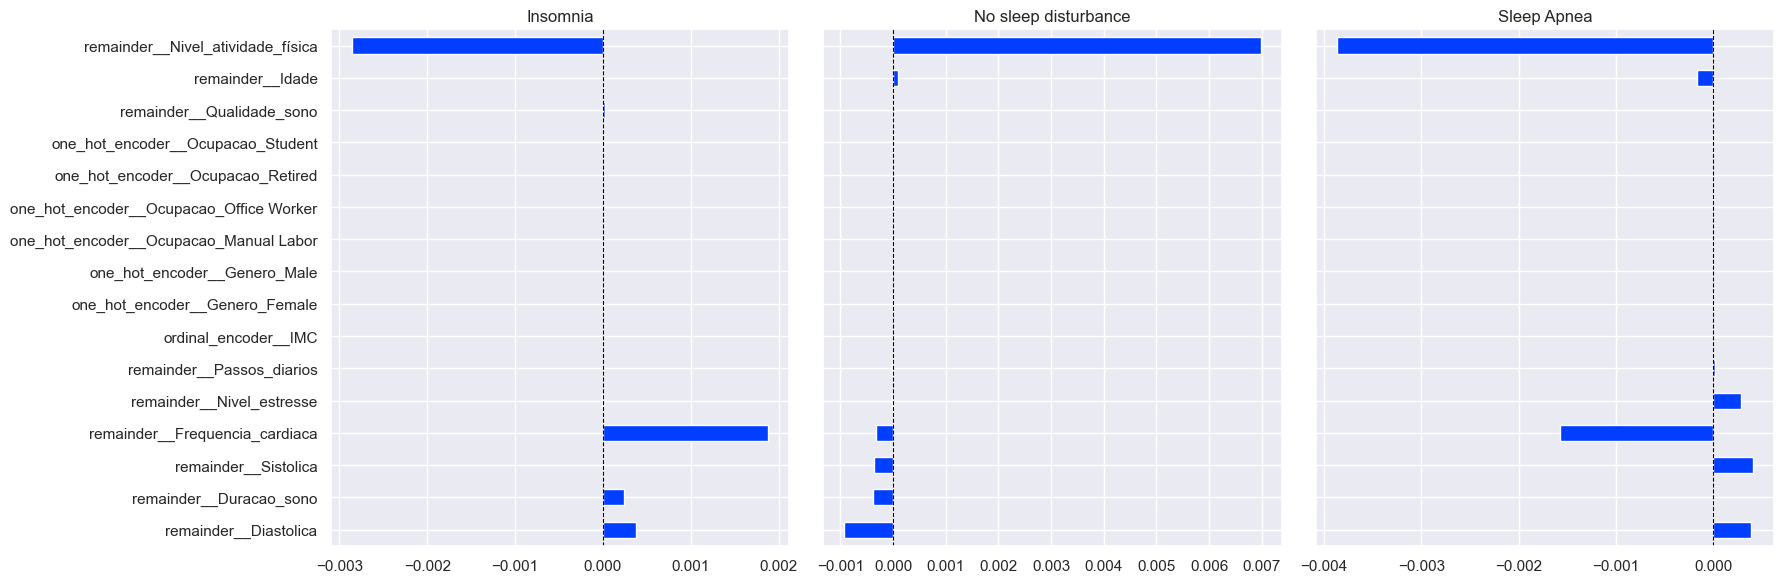

In [34]:
# Criando um gráfico de barras para demonstrar a magnitude dos coeficientes

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, coluna in enumerate(coefs.columns):
    coefs[coluna].plot(
        kind='barh', 
        ax=axs[i], 
        title=coluna
    )
    axs[i].axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

Conforme observado no notebook do modelo inicial, podemos observar a presença de muitos coeficientes positivos e negativos com alguma relevância sobre o modelo. 

Entretanto, nesse modelo otimizado, houve a redução no número de features que influenciam o modelo (especialmente variáveis categóricas como gênero e ocupação). Isso sugere que a regularização L1 (Lasso) reduziram a importância dessas variáveis, possivelmente porque não traziam ganho real de explicação.

Quanto a as variáveis que se mantiveram relevantes: 
- **Frequência cardíaca** continua com coeficientes relativamente maiores (positivos para Insônia, negativos para Apneia), mostrando que é uma variável importante para diferenciar distúrbios do sono.
- **Nível de atividade física** também permanece com peso significativo, especialmente em “No sleep disturbance” (coeficiente positivo), sugerindo associação com melhor qualidade de sono.
- **Pressão arterial (Diastólica e Sistólica)** e **Duração do sono** ainda aparecem, mas com magnitudes menores, indicando influência moderada.

## Conclusão

Neste notebook exploramos diferentes alternativas para reduzir o desbalanceamento dos dados. Observamos que, apesar de não haver uma melhoria significativa nas métricas de desempenho, o uso do RandomUnderSampler trouxe ganhos ao reduzir o tempo de execução, tornando o processo mais eficiente.

Além disso, aplicamos o Grid Search para otimizar o modelo, o que contribuiu para a simplificação da solução, eliminando variáveis com pouca relevância e concentrando o aprendizado nas features mais importantes. O resultado foi um modelo mais enxuto e mais fácil de interpretar, reduzindo o ruído e mais eficiente.

## Próximas Análises:

Na próxima etapa vamos explorar outros modelos como os baseados em árvores (DecisionTreeClassifier e RandomForestClassifier). Após isso, modelos baseados em Gradient Boosting (XGboost e LightGBM).